# Fig. S5: Infotaxis vs MAP comparison: PFA=0, PM sweep

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from infotaxis import one_target

from scipy import stats

import seaborn as sns

In [2]:
path_csv = Path("../simulations/20251113_summary_refined")

path_fig = Path("../figs")

In [3]:
def load_summary(search_type, cr, br, pm, pfa):
    return pd.read_csv(
        path_csv / f"{search_type}_cr{cr}_br{br}_pm{pm:.0e}_pfa{pfa:.0e}_summary.csv",
        index_col=0
    )

In [4]:
def get_stats(x, y, print_stats=True):
    stats_dict = dict()
    stats_dict["two-sided"] = stats.mannwhitneyu(x, y, alternative="two-sided")
    stats_dict["less"] = stats.mannwhitneyu(x, y, alternative="less")
    stats_dict["greater"] = stats.mannwhitneyu(x, y, alternative="greater")

    if print_stats:
        print(f"Samples: infotaxis: {len(x):4d}    MAP: {len(y):4d}")
        print(f"Mean:    infotaxis: {np.mean(x):.3f}  MAP: {np.mean(y):.3f}")
        print(f"Median:  infotaxis: {np.median(x):.3f}  MAP: {np.median(y):.3f}")
        print("")
        print("MWU test")
        print(f" - different: {stats_dict["two-sided"].pvalue:.5f}")
        print(f" - less:      {stats_dict["less"].pvalue:.5f}")
        print(f" - greater:   {stats_dict["greater"].pvalue:.5f}")

    return stats_dict

In [5]:
def bar_violinplot_success(
    cr, br, pm_all, pfa_fixed, alpha = 0.65, ping_bins=np.arange(0, 155, 5), print_stats=True
):

    # Get search space grid info
    search_dict = None
    param_echo = {
        str(br): {
            "pm_const": 0.001,
            "pfa_const": 0.001,
        },
    }
    oth = one_target.OneTargetHex(
        search_rule="infotaxis",
        canvas_radius=cr,
        beam_radius=[br],
        target_cube=(0, 0, 0),
        aim_start_cube=(-2, 3, -1),
        param_animal= param_echo,
        param_echo= param_echo,
        search_dict=search_dict
    )

    grid_in_beam = oth.beam_cover_last_cube.shape[0]
    grid_in_space = oth.canvas_cube.shape[0]
    alpha_grid = grid_in_beam / grid_in_space

    # Get colors for plotting
    colors = sns.color_palette("Set2")
    colors_dark = sns.color_palette("Dark2")

    # Plot
    colors = sns.color_palette("Set2")
    colors_dark = sns.color_palette("Dark2")

    fig, axes = plt.subplots(
        2, len(pm_all), figsize=(6, 4.5), sharey="row",
        gridspec_kw={'height_ratios': [1, 3], 'hspace': 0.05, "wspace": 0}  # Top row is 1/3 height of bottom
    )

    for idx, pm in enumerate(pm_all):

        # Load summary and ph details
        df_infotaxis = load_summary("infotaxis", cr, br, pm, pfa_fixed)
        df_MAP = load_summary("MAP", cr, br, pm, pfa_fixed)

        # Plot only runs with 1 grid left
        x = df_infotaxis[df_infotaxis["num_grid_left"]==1]["num_pings_2conditions"].values
        y = df_MAP[df_MAP["num_grid_left"]==1]["num_pings_2conditions"].values

        # Print statistics
        stats_dict = get_stats(x, y, print_stats)


        # Plotting success rate
        ax_s = axes[0, idx]
        bar_x = ax_s.bar(-0.5, len(x)/1000*100, width=0.4, color=colors[0], alpha=alpha)
        bar_y = ax_s.bar(0.5, len(y)/1000*100, width=0.4, color=colors[1], alpha=alpha)
        ax_s.text(-0.5, len(x)/1000*100+5, (f"({len(x)})"), ha="center", va="bottom", fontsize=9)
        ax_s.text(0.5, len(y)/1000*100+5, (f"({len(y)})"), ha="center", va="bottom", fontsize=9)
        ax_s.set_xlim(-1, 1)
        ax_s.set_ylim(0, 140)
        ax_s.set_title(f"{pm}")


        # Plotting number of pings to success
        ping_bins = np.arange(0, np.ceil(np.hstack((x, y)).max())+10, 5)

        ax_n = axes[1, idx]

        x_hist, x_bins = np.histogram(x, bins=ping_bins, density=True)
        y_hist, y_bins = np.histogram(y, bins=ping_bins, density=True)
        x_median = np.median(x)
        y_median = np.median(y)

        ax_n.barh(x_bins[:-1], -x_hist, height=np.diff(x_bins), left=0, align="edge", edgecolor="w", color=colors[0], alpha=alpha)
        ax_n.barh(y_bins[:-1], y_hist, height=np.diff(x_bins), left=0, align="edge", edgecolor="w", color=colors[1], alpha=alpha)        
        ax_s.set_xticks([])
        ax_s.set_xticklabels("")

        # Get x-axis limits
        xlim = ax_n.get_xlim()
        xlim = np.max([max(xlim), -min(xlim)])
        xlim = xlim + 0.1*np.max(xlim)
        ax_n.set_xlim(-xlim, xlim)
        ax_n.axhline(x_median, xmin=0.0, xmax=0.5, color=colors_dark[0], solid_capstyle="butt", lw=2.5)
        ax_n.axhline(y_median, xmin=0.51, xmax=1, color=colors_dark[1], solid_capstyle="butt", lw=2.5)

        # label sample number
        ax_n.set_xticks([])
        ax_n.set_xticklabels("")
        
        # label p-value for alternative="less"
        ax_n.text(
            0.975, 0.93, f"p={stats_dict["less"].pvalue:.0e}",
            ha="right", va="center",
            transform=ax_n.transAxes,
            fontsize=11, 
        )

        ax_n.tick_params(direction='in', which='both')
        if idx != 0:
            if ping_bins[-1] > 200:
                ax_n.set_yticks(ping_bins[::8])
            else:
                ax_n.set_yticks(ping_bins[::4])

    # make title line
    axes[0, 0].text(
        -2.75, 1.04, r"$P_M$=",
        ha="right", va="bottom",
        transform=ax_s.transAxes,
        fontsize=12,
    )

    axes[0, 0].set_ylabel("Success\nrate (%)", fontsize=12)    
    axes[1, 0].set_ylabel("Number of pings\nto success", fontsize=12)
    fig.text(0.5, 0.98, fr"$\mathbfit{{P_{{FA}}}}$=0, $\mathbfit{{\alpha}}$={alpha_grid:.3f}  ($\mathbfit{{r_A}}$={cr}, $\mathbfit{{r_B}}$={br})",
        ha="center", va="center", fontsize=12, fontweight="bold")
    # fig.text(0.5, 0.97, fr"Space radius={cr}, footprint radius={br} ($\alpha$={alpha_grid:.3f})",
    #     ha="center", va="center", fontsize=12)

   # Add single horizontal legend below all panels
    fig.legend(
        handles=[bar_x, bar_y],
        labels=['Infotaxis', 'MAP'],
        loc='lower center',
        ncol=2,
        bbox_to_anchor=(0.5, 0.005),
        # frameon=False,
        fontsize=11
    )    

    # plt.tight_layout(pad=0)
    plt.show()

    return fig

## Number of pings until finding 1 grid

Initial beam aim is given, but not initial beam radius.
Set initial beam radius to the largest of beam radius choices: 1


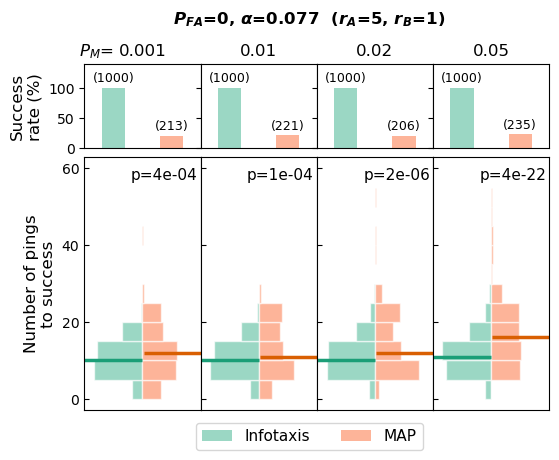

In [6]:
cr = 5
br = 1
# pfa_all = [0.001, 0.005, 0.01, 0.05]
pfa_all = [0.001, 0.01, 0.02, 0.05]
pm_fixed = 0

fig = bar_violinplot_success(cr, br, pfa_all, pm_fixed, print_stats=False)

fig.savefig(path_fig / f"fig_S4A_infotaxis_MAP_cmp_pfa0_cr{cr}_br{br}.png", dpi=300, bbox_inches="tight")

Initial beam aim is given, but not initial beam radius.
Set initial beam radius to the largest of beam radius choices: 2


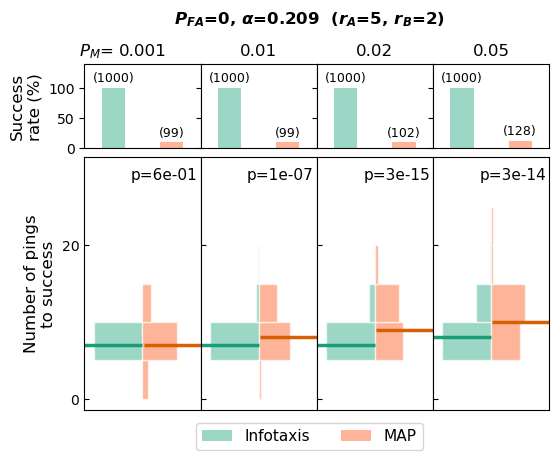

In [7]:
cr = 5
br = 2
# pfa_all = [0.001, 0.005, 0.01, 0.05]
pfa_all = [0.001, 0.01, 0.02, 0.05]
pm_fixed = 0

fig = bar_violinplot_success(cr, br, pfa_all, pm_fixed, print_stats=False)

fig.savefig(path_fig / f"fig_S4B_infotaxis_MAP_cmp_pfa0_cr{cr}_br{br}.png", dpi=300, bbox_inches="tight")

Initial beam aim is given, but not initial beam radius.
Set initial beam radius to the largest of beam radius choices: 1


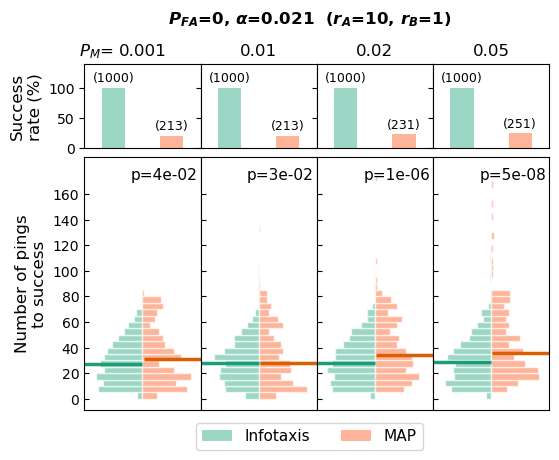

In [8]:
cr = 10
br = 1
# pfa_all = [0.001, 0.005, 0.01, 0.05]
pfa_all = [0.001, 0.01, 0.02, 0.05]
pm_fixed = 0

fig = bar_violinplot_success(cr, br, pfa_all, pm_fixed, print_stats=False)

fig.savefig(path_fig / f"fig_S4C_infotaxis_MAP_cmp_pfa0_cr{cr}_br{br}.png", dpi=300, bbox_inches="tight")

Initial beam aim is given, but not initial beam radius.
Set initial beam radius to the largest of beam radius choices: 2


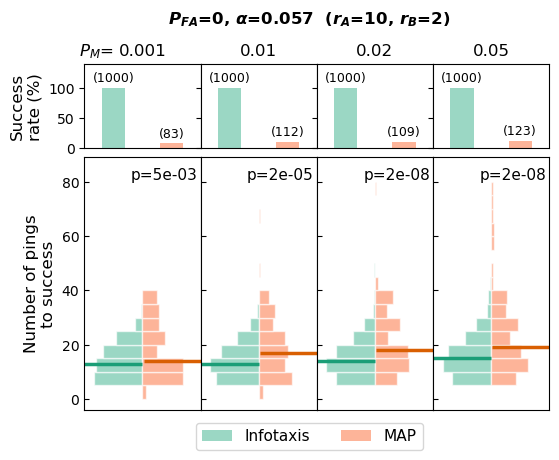

In [9]:
cr = 10
br = 2
# pfa_all = [0.001, 0.005, 0.01, 0.05]
pfa_all = [0.001, 0.01, 0.02, 0.05]
pm_fixed = 0

fig = bar_violinplot_success(cr, br, pfa_all, pm_fixed, print_stats=False)

fig.savefig(path_fig / f"fig_S4D_infotaxis_MAP_cmp_pfa0_cr{cr}_br{br}.png", dpi=300, bbox_inches="tight")

## Number of grids left

Initial beam aim is given, but not initial beam radius.
Set initial beam radius to the largest of beam radius choices: 1
Initial beam aim is given, but not initial beam radius.
Set initial beam radius to the largest of beam radius choices: 2


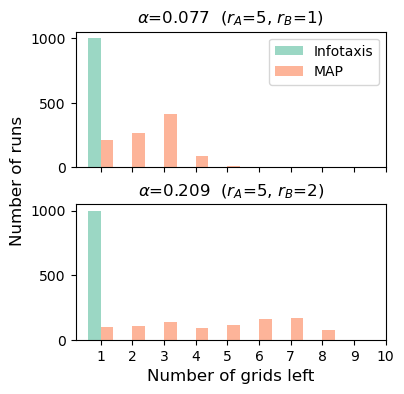

In [10]:
pm = 0.001
pfa = 0

colors = sns.color_palette("Set2")
alpha = 0.65

fig, ax_n = plt.subplots(2, 1, figsize=(4, 4), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.27)

cr = 5
for br_seq, br in enumerate([1, 2]):

    search_dict = None
    param_echo = {
        str(br): {
            "pm_const": 0.001,
            "pfa_const": 0.001,
        },
    }
    oth = one_target.OneTargetHex(
        search_rule="infotaxis",
        canvas_radius=cr,
        beam_radius=[br],
        target_cube=(0, 0, 0),
        aim_start_cube=(-2, 3, -1),
        param_animal= param_echo,
        param_echo= param_echo,
        search_dict=search_dict
    )

    grid_in_beam = oth.beam_cover_last_cube.shape[0]
    grid_in_space = oth.canvas_cube.shape[0]
    alpha_grid = grid_in_beam / grid_in_space

    # Load summary and ph details
    df_infotaxis = load_summary("infotaxis", cr, br, pm, pfa)
    df_MAP = load_summary("MAP", cr, br, pm, pfa)

    bins = np.arange(1, 10)-0.5

    ax_n[br_seq].hist(
        [df_infotaxis["num_grid_left"], df_MAP["num_grid_left"]],
        bins=bins, color=[colors[0], colors[1]], alpha=alpha
    )
    ax_n[br_seq].set_title(
        fr"$\alpha$={alpha_grid:.3f}  ($r_A$={cr}, $r_B$={br})",
        fontsize=12, #fontweight="bold"
    )

ax_n[0].legend(["Infotaxis", "MAP"])
ax_n[0].set_xticks(np.arange(1, 11))
ax_n[1].set_xlabel("Number of grids left", fontsize=12)
ax_n[0].set_ylabel("Number of runs                               ", fontsize=12)

plt.show()